# Tutorial: Facial Expressions and Morphology with `mozza_mesh`

This notebook is a beginner-friendly guide to the **`mozza_mesh`** GStreamer plugin. It changes **facial expressions** (action units, AUs) and **facial morphology** (how dominant or trustworthy a face looks) on images and live video, for DuckSoup experiments.

### What are we going to do?
1. **Setup**: get the Docker image, build the plugin and download the face model.
2. **Check detection**: see the landmarks the plugin tracks.
3. **Make someone smile**: one expression, stronger, and reversed.
4. **All the expressions**: the nine AUs available.
5. **Morphology**: dominance and trustworthiness.
6. **Combine** expressions and morphology.
7. **Video**: constant transformations, and transformations that change over time (as in a live experiment).
8. **Dominance and trustworthiness on video**, changing dynamically on two 30 s videos of people talking.
9. **Parameters, speed, and use in DuckSoup.**

### How is it different from `mozza_mp` (see `mozza_mp_tutorial.ipynb`)?
- `mozza_mp` moves landmarks with rules from a `.dfm` file and one `alpha` intensity.
- `mozza_mesh` uses **fields**: for each transformation, how every face landmark moves at amplitude 1. Fields are stored in **basis files** (`gstmozzamesh/bases/`), built and validated in [face-transforms](https://github.com/Pablo-Arias/face-transforms).
- You choose an **amplitude** for each transformation (any number at once), and you can change them while a video plays.
- The image follows with a **mesh warp**: every landmark lands exactly where the field puts it, and the background doesn't move.

---
## 1. Getting Started with Docker

### Step A: Install Docker
Before running any code, you need **Docker Desktop** installed and running on your computer.
- [Download for Windows](https://docs.docker.com/desktop/install/windows-install/)
- [Download for Mac](https://docs.docker.com/desktop/install/mac-install/)
- [Download for Linux](https://docs.docker.com/desktop/install/linux-install/)

### Step B: Verify Docker
Run the cell below. If you see a version number, you are ready!

In [1]:
!docker --version

Docker version 29.8.1, build 4a63305


---
## 2. Setup: Pull the Image, Build the Plugin, Download the Model

### Pull the plugins image
If you are working on a desktop machine, open Docker Desktop and log in. Then download the pre-built plugins image:

In [2]:
!docker pull ducksouplab/mp_plugins:latest
!docker tag ducksouplab/mp_plugins:latest mp_plugins:latest

latest: Pulling from ducksouplab/mp_plugins
Digest: sha256:75b389d198707e5c9a5eb78f96bda725cfe3e31a638d8ba04c69616881659cee
Status: Image is up to date for ducksouplab/mp_plugins:latest
docker.io/ducksouplab/mp_plugins:latest


### Build `mozza_mesh`
The published image doesn't contain `mozza_mesh` yet, so build it once. This uses the same base image as the official build and takes a few seconds (the first time, Docker also downloads the build image). The Python wrapper then loads the plugin from `gstmozzamesh/out/` into the image.

In [3]:
!cd .. && docker build -q --platform linux/amd64 -t mozza-mesh-dev gstmozzamesh/dev
!cd .. && docker run --rm --platform linux/amd64 -v "$PWD":/src -w /src mozza-mesh-dev gstmozzamesh/dev/build.sh

sha256:e6082b9d7f50078516c4e1c966bb91cd9079b5f07bba99d4da928948279f7e13


built: facewarp_cli
libgstmozzamesh.so
video_lm.txt


### Download the MediaPipe model
The face-tracking model file (skipped if it's already there):

In [4]:
!cd .. && [ -f face_landmarker.task ] || (chmod +x download_face_landmarker_model.sh && ./download_face_landmarker_model.sh)

### Import the wrapper
`mesh_process.py` runs the plugin in Docker for you, like `mozza_process.py` for `mozza_mp`. It has two functions: `transform_image` and `transform_video`. We also define `sheet()`, a small helper that shows several results side by side.

In [5]:
import os
import sys

# Add the parent directory to the path so we can import the wrapper
sys.path.append("..")
from mesh_process import transform_image, transform_video

from IPython.display import Video, display
from PIL import Image, ImageDraw

root_dir = os.path.abspath("..")
input_img = os.path.join(root_dir, "media", "inputs", "test_image.jpg")
out = os.path.join(root_dir, "media", "outputs", "mozza_mesh_tutorial")
os.makedirs(out, exist_ok=True)


def sheet(paths, labels, scale=0.6, box=(150, 60, 590, 520)):
    """Show images side by side (cropped to the face), each with a label."""
    ims = [Image.open(p).convert("RGB").crop(box) for p in paths]
    w, h = int(ims[0].width * scale), int(ims[0].height * scale)
    s = Image.new("RGB", (w * len(ims), h + 18), "white")
    d = ImageDraw.Draw(s)
    for i, (im, label) in enumerate(zip(ims, labels)):
        s.paste(im.resize((w, h)), (i * w, 18))
        d.text((i * w + 4, 3), label, fill="black")
    return s

---
## 3. Step 1: Check the Face Is Detected

With no amplitudes, the plugin leaves the image unchanged. With `show_landmarks=True`, it draws the landmarks it tracks: everything below moves these points and warps the image to follow.

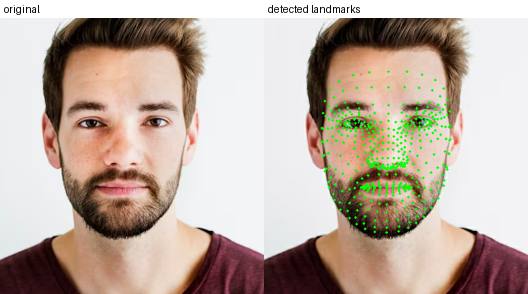

In [6]:
transform_image(input_img, f"{out}/landmarks.png", show_landmarks=True)
display(sheet([input_img, f"{out}/landmarks.png"], ["original", "detected landmarks"]))

---
## 4. Step 2: Make Someone Smile

`transform_image(input, output, amplitudes)` takes a dictionary `{transformation: amplitude}`. `AU12` is the *lip corner puller*, the main smile movement. For AUs, **1 = a clear, plausible expression**.

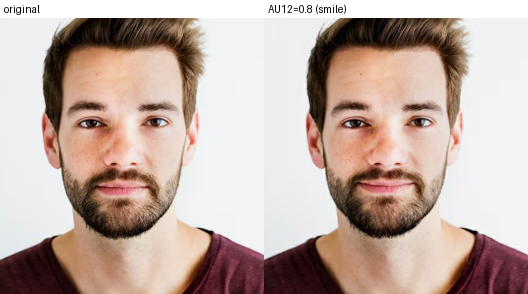

In [7]:
transform_image(input_img, f"{out}/smile.png", {"AU12": 0.8})
display(sheet([input_img, f"{out}/smile.png"], ["original", "AU12=0.8 (smile)"]))

Make the smile stronger by raising the amplitude. Above about 1.5, expressions start to look exaggerated:

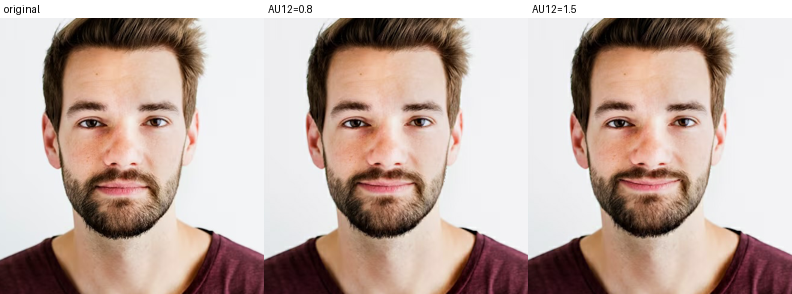

In [8]:
transform_image(input_img, f"{out}/smile_strong.png", {"AU12": 1.5})
display(sheet([input_img, f"{out}/smile.png", f"{out}/smile_strong.png"],
              ["original", "AU12=0.8", "AU12=1.5"]))

Or reverse it with a **negative amplitude**: the lip corners go down instead of up.

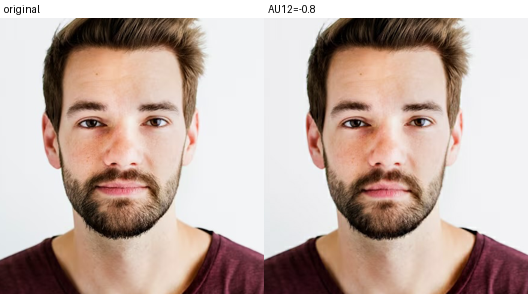

In [9]:
transform_image(input_img, f"{out}/smile_reversed.png", {"AU12": -0.8})
display(sheet([input_img, f"{out}/smile_reversed.png"], ["original", "AU12=-0.8"]))

---
## 5. Step 3: All the Facial Expressions (AUs)

Basis v1 has nine action units. Each one at -1 (reversed), unchanged, and +1:

| AU | Name | AU | Name | AU | Name |
|---|---|---|---|---|---|
| AU1 | inner brow raiser | AU5 | upper lid raiser | AU12 | lip corner puller |
| AU2 | outer brow raiser | AU7 | lid tightener | AU15 | lip corner depressor |
| AU4 | brow lowerer | AU43 | eye closure | AU20 | lip stretcher |

A 2D warp only moves the skin: it can't add wrinkles, teeth or an open mouth.

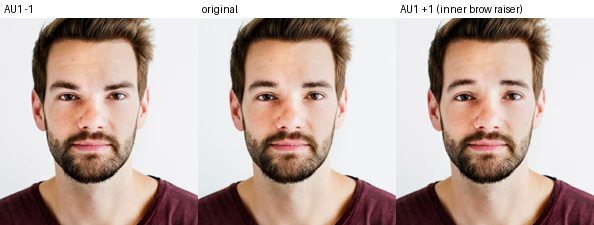

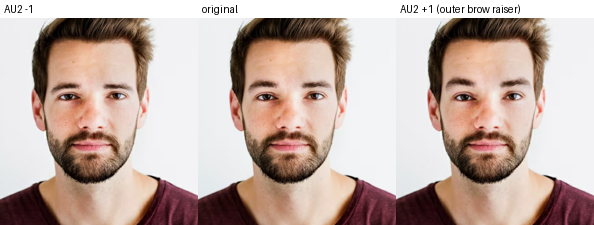

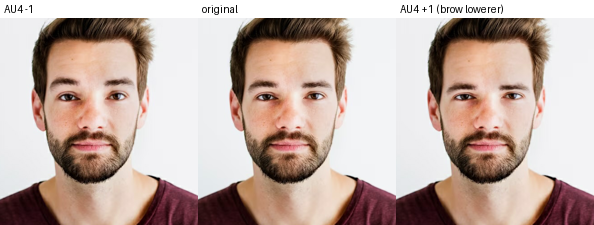

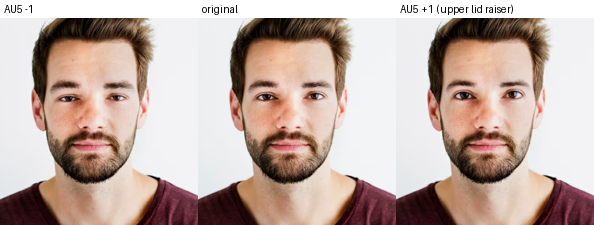

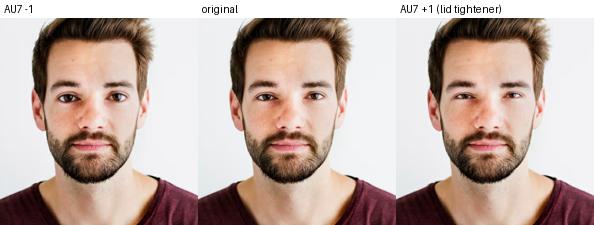

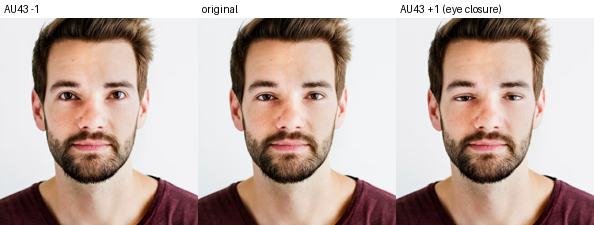

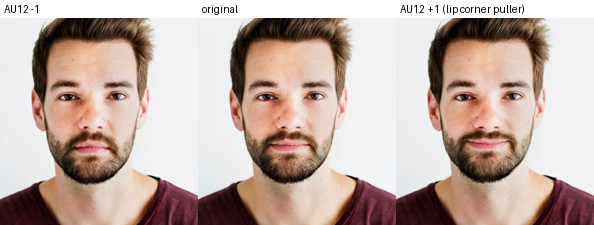

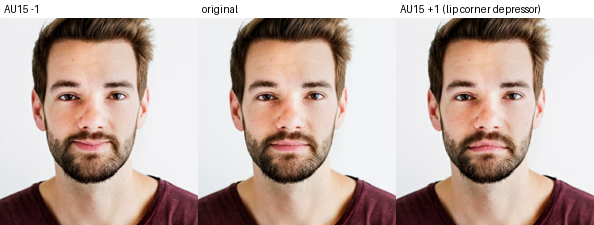

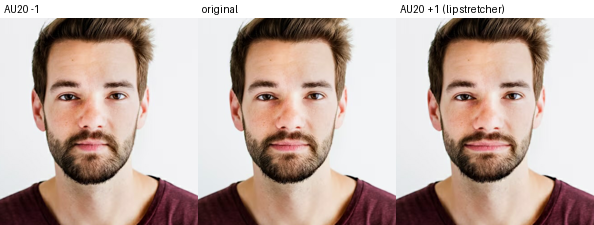

In [10]:
aus = {"AU1": "inner brow raiser", "AU2": "outer brow raiser", "AU4": "brow lowerer",
       "AU5": "upper lid raiser", "AU7": "lid tightener", "AU43": "eye closure",
       "AU12": "lip corner puller", "AU15": "lip corner depressor", "AU20": "lip stretcher"}

for au, name in aus.items():
    minus, plus = f"{out}/{au}_-1.png", f"{out}/{au}_+1.png"
    transform_image(input_img, minus, {au: -1})
    transform_image(input_img, plus, {au: 1})
    display(sheet([minus, input_img, plus], [f"{au} -1", "original", f"{au} +1 ({name})"], scale=0.45))

---
## 6. Step 4: Morphology (Dominance and Trustworthiness)

These fields were extracted from the face models of Oosterhof & Todorov (2008). Amplitudes are in **standard deviations (SD)** of their models, whose faces span -3 to +3 SD.
- `DOM_o` and `TRUST_o` are an **orthogonal pair**: changing one doesn't change the other. Use these by default.
- `DOM`, `TRUST` and `THREAT` are the original models (dominance and trustworthiness are correlated there).

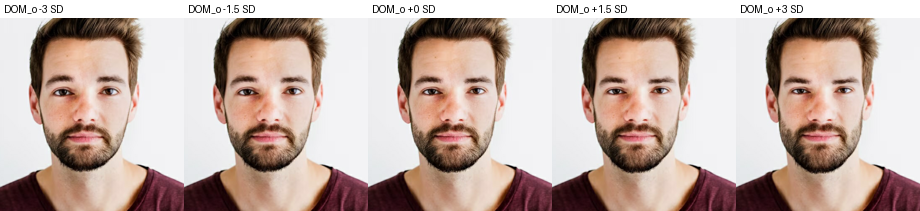

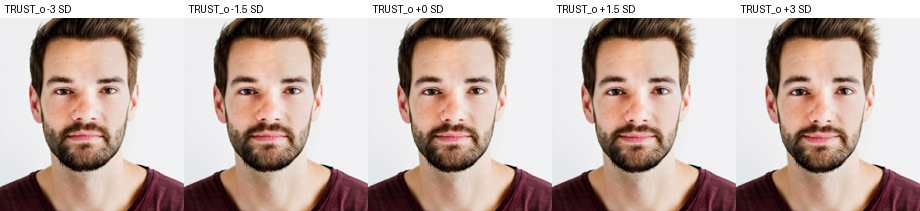

In [11]:
for trait in ("DOM_o", "TRUST_o"):
    paths, labels = [], []
    for sd in (-3, -1.5, 0, 1.5, 3):
        path = f"{out}/{trait}_{sd:+g}.png"
        transform_image(input_img, path, {trait: sd})
        paths.append(path)
        labels.append(f"{trait} {sd:+g} SD")
    display(sheet(paths, labels, scale=0.42))

---
## 7. Step 5: Combine Expressions and Morphology

Transformations add up, whatever basis file they come from. Here a dominant, untrustworthy face, then the same face smiling:

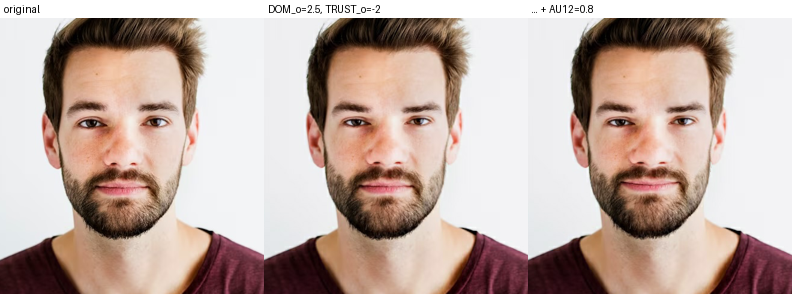

In [12]:
transform_image(input_img, f"{out}/combo1.png", {"DOM_o": 2.5, "TRUST_o": -2})
transform_image(input_img, f"{out}/combo2.png", {"DOM_o": 2.5, "TRUST_o": -2, "AU12": 0.8})
display(sheet([input_img, f"{out}/combo1.png", f"{out}/combo2.png"],
              ["original", "DOM_o=2.5, TRUST_o=-2", "... + AU12=0.8"]))

**Folds.** Very strong combinations can make the skin fold over itself (for example eye closure and lid tightener both well above 1). The plugin's *fold guard* (`fold_guard`, default 5 px²) detects this and scales the deformation down until it no longer folds; `fold_guard=-1` turns it off. Keeping amplitudes in the sensible ranges (about ±1.5 for AUs, ±3 SD for traits) avoids it.

---
## 8. Step 6: Process a Video

`transform_video` works the same way. With **constant amplitudes**, every frame gets the same transformation, and the plugin tracks the face as it moves:

In [13]:
input_video = os.path.join(root_dir, "media", "inputs", "video_example.mp4")
transform_video(input_video, f"{out}/video_smile.mp4", {"AU12": 0.8, "AU1": 0.5})
Video("../media/outputs/mozza_mesh_tutorial/video_smile.mp4", embed=False, width=480)

### Amplitudes that change over time
In an experiment, transformations usually appear, change and disappear while the participant is on camera. `keyframes=[(seconds, {transformation: amplitude}), ...]` sets amplitudes at given times, interpolated linearly in between, exactly what DuckSoup's `controlFx(..., duration)` does live.

Here the face starts neutral, a smile builds up over 1 s, then the smile goes and the face becomes dominant:

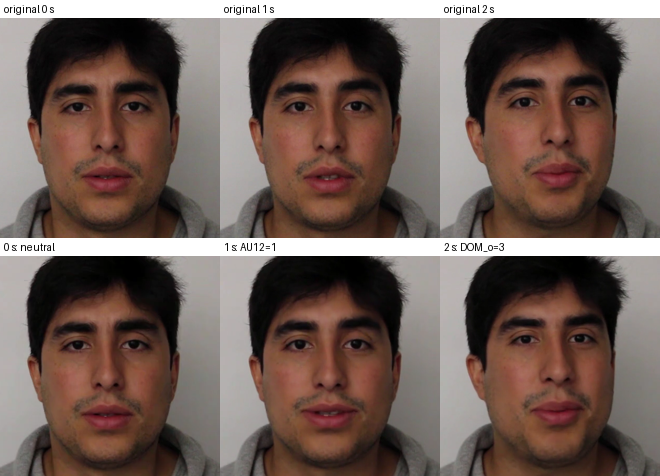

In [14]:
os.environ.setdefault("OPENCV_FFMPEG_LOGLEVEL", "-8")  # silence decoder warnings on damaged frames
import cv2


def frames_at(path, times, box):
    """Video frames at the given times (seconds), cropped to `box`.

    Reads the video in order rather than seeking, which is exact even for
    videos with a variable frame rate (common for webcam recordings).
    """
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    wanted = {int(round(t * fps)): t for t in times}
    found, k = {}, 0
    while len(found) < len(wanted):
        ok, f = cap.read()
        if not ok:
            break
        if k in wanted:
            found[wanted[k]] = Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)).crop(box)
        k += 1
    cap.release()
    return [found[t] for t in times]


def filmstrip(original, transformed, times, labels, box, size=220):
    """Original frames (top row) above transformed frames (bottom row), at the given times."""
    rows = [frames_at(original, times, box), frames_at(transformed, times, box)]
    s = Image.new("RGB", (size * len(times), 2 * (size + 18)), "white")
    d = ImageDraw.Draw(s)
    for r, (row, names) in enumerate(zip(rows, [[f"original {t:g} s" for t in times], labels])):
        for i, (im, label) in enumerate(zip(row, names)):
            s.paste(im.resize((size, size)), (size * i, r * (size + 18) + 18))
            d.text((size * i + 4, r * (size + 18) + 3), label, fill="black")
    return s


keys = [(0, {"AU12": 0}), (1.0, {"AU12": 1}), (2.0, {"AU12": 0, "DOM_o": 3})]
transform_video(input_video, f"{out}/video_keyframes.mp4", keyframes=keys)

face_box = (562, 112, 982, 532)  # the face in media/inputs/video_example.mp4
display(filmstrip(input_video, f"{out}/video_keyframes.mp4", (0, 1, 2),
                  ["0 s: neutral", "1 s: AU12=1", "2 s: DOM_o=3"], face_box))
Video("../media/outputs/mozza_mesh_tutorial/video_keyframes.mp4", embed=False, width=480)

---
## 9. Step 7: Dominance and Trustworthiness on Video

The morphology transformations work on video too, and their amplitudes can change while the person talks, as in a DuckSoup experiment where a participant's face becomes gradually more dominant or more trustworthy during a conversation.

We use two 30 s videos in `media/inputs/`: `sentences_1F_30s.mp4` and `sentences_1M_30s.mp4`. Each is a series of short sentences recorded in the lab and joined into one continuous video, so the transformation has to follow a face that talks, blinks and moves its head.

`side_by_side_video(original, transformed, output, keyframes=...)` (in `mesh_process.py`) puts the original and the transformed video next to each other, with the current amplitudes written on each frame.

The schedule below changes dominance, then trustworthiness:

| Time | What happens |
|---|---|
| 0-3 s | unchanged |
| 3-7 s | becomes dominant (`DOM_o` 0 → +3) |
| 7-11 s | stays dominant |
| 11-14 s | from dominant to submissive (`DOM_o` +3 → -3) |
| 17-19 s | back to unchanged |
| 19-22 s | becomes trustworthy (`TRUST_o` 0 → +3) |
| 25-28 s | from trustworthy to untrustworthy (`TRUST_o` +3 → -3) |

In DuckSoup, the same schedule is a series of calls such as `controlFx("fx", "dom", 3, 4000)` (see section 12).

In [15]:
from mesh_process import side_by_side_video

experiment = [
    (0,  {"DOM_o": 0,  "TRUST_o": 0}),
    (3,  {"DOM_o": 0,  "TRUST_o": 0}),
    (7,  {"DOM_o": 3,  "TRUST_o": 0}),
    (11, {"DOM_o": 3,  "TRUST_o": 0}),
    (14, {"DOM_o": -3, "TRUST_o": 0}),
    (17, {"DOM_o": -3, "TRUST_o": 0}),
    (19, {"DOM_o": 0,  "TRUST_o": 0}),
    (22, {"DOM_o": 0,  "TRUST_o": 3}),
    (25, {"DOM_o": 0,  "TRUST_o": 3}),
    (28, {"DOM_o": 0,  "TRUST_o": -3}),
]

speakers = {"1F": (457, 70, 877, 490),   # crop box around each face, for the close-ups below
            "1M": (435, 90, 855, 510)}

for name in speakers:
    original = os.path.join(root_dir, "media", "inputs", f"sentences_{name}_30s.mp4")
    transform_video(original, f"{out}/sentences_{name}_traits.mp4", keyframes=experiment)
    side_by_side_video(original, f"{out}/sentences_{name}_traits.mp4",
                       f"{out}/sentences_{name}_traits_side_by_side.mp4", keyframes=experiment)

### A. Speaker 1F

In [16]:
Video("../media/outputs/mozza_mesh_tutorial/sentences_1F_traits_side_by_side.mp4", embed=False, width=800)

### B. Speaker 1M

In [17]:
Video("../media/outputs/mozza_mesh_tutorial/sentences_1M_traits_side_by_side.mp4", embed=False, width=800)

### C. The key moments, close up
Top row: original. Bottom row: transformed, at the peak of each phase. Morphology changes are subtler than expressions: they change the face's proportions (brows, eyes, jaw and mouth shape), not its movement.

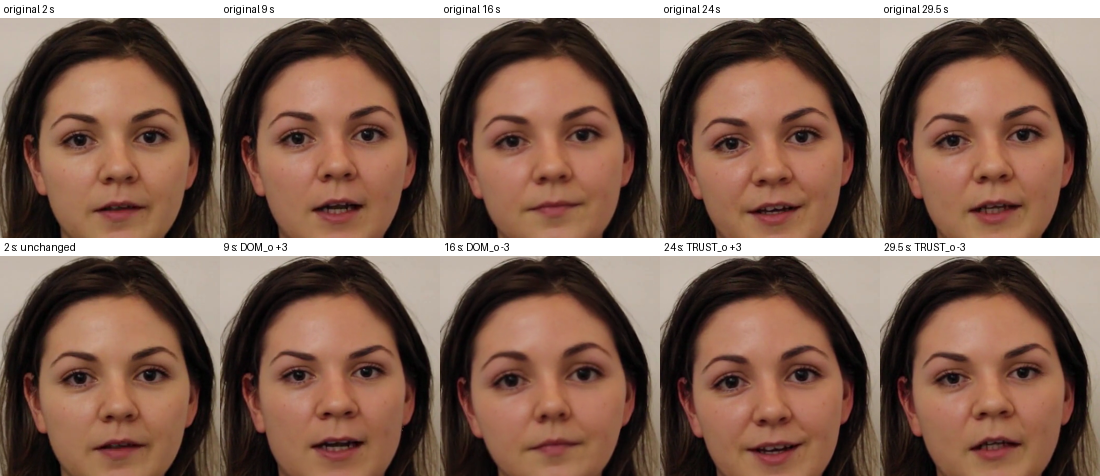

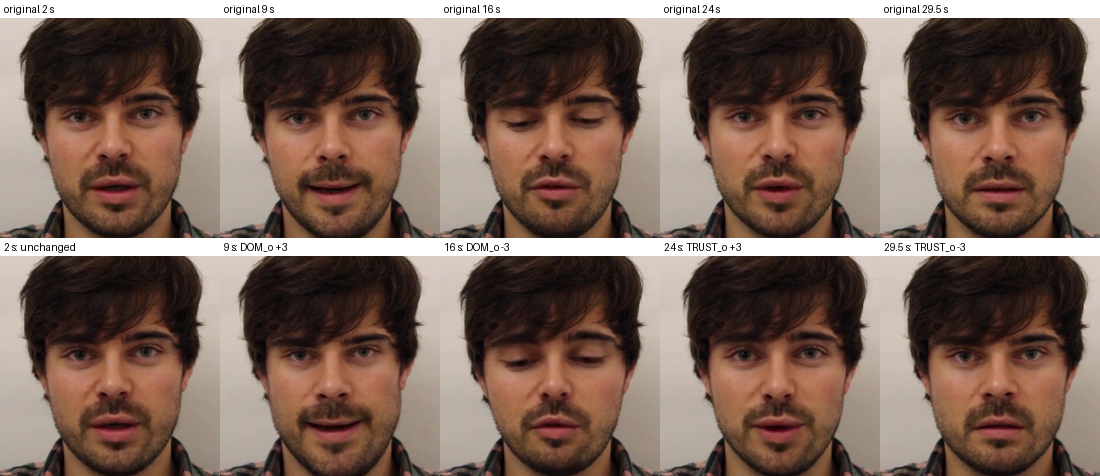

In [18]:
times = (2, 9, 16, 24, 29.5)
labels = ["2 s: unchanged", "9 s: DOM_o +3", "16 s: DOM_o -3", "24 s: TRUST_o +3", "29.5 s: TRUST_o -3"]
for name, box in speakers.items():
    original = os.path.join(root_dir, "media", "inputs", f"sentences_{name}_30s.mp4")
    display(filmstrip(original, f"{out}/sentences_{name}_traits.mp4", times, labels, box, size=220))

---
## 10. Advanced Customization

### A. The parameters
Both `transform_image` and `transform_video` take:
- `amplitudes`: `{transformation: amplitude}`. AU names (`"AU12"`...) and trait names (`"DOM_o"`, `"TRUST_o"`, `"DOM"`, `"TRUST"`, `"THREAT"`). Anything not listed stays at 0.
- `show_landmarks`: `True` to draw the tracked landmarks, `False` for a realistic result.
- `fold_guard`: maximum folded skin area in px² before the deformation is scaled down (`-1` = off).
- `basis`: the basis files to load (default: both v1 files in `gstmozzamesh/bases/`).

`transform_video` also takes `keyframes` (instead of `amplitudes`), `smooth` (temporal smoothing of the landmarks, on by default) and `log_every` (see section 11).

### B. The basis files
Each basis file is a JSON file with named fields. A field lists, for each of MediaPipe's 468 face landmarks, its displacement `[dx, dy]` at amplitude 1, measured relative to the distance between the outer eye corners. So the same field works for any face size, position or head tilt. Each frame, the plugin computes `displacement = Σ amplitude × field` on the tracked face and warps the image.

New or improved transformations are new basis files (v2...), with no change to the plugin. The transformations available in the loaded files:

In [19]:
import json

for name in ("au_basis_v1.json", "trait_basis_v1.json"):
    with open(os.path.join(root_dir, "gstmozzamesh", "bases", name)) as f:
        fields = json.load(f)["fields"]
    print(f"{name}: {', '.join(fields)}  ({len(next(iter(fields.values())))} landmarks each)")

au_basis_v1.json: AU1, AU2, AU4, AU5, AU43, AU7, AU12, AU20, AU15  (468 landmarks each)
trait_basis_v1.json: TRUST_o, DOM_o, TRUST, DOM, THREAT  (468 landmarks each)


### C. Attribution
The basis files are for non-commercial research. If you use them, cite RAVDESS (Livingstone & Russo, 2018) for the AU basis and Oosterhof & Todorov (2008) for the trait basis. Full references are in `gstmozzamesh/bases/README.md`.

---
## 11. Performance Monitoring

With `log_every`, the plugin prints how long each step takes, every N frames:
- **detect**: time to find the landmarks (MediaPipe).
- **warp**: time to compute and apply the deformation.

On a Mac, the plugin runs under x86 emulation, so these times are much slower than on a Linux server.

In [20]:
transform_video(input_video, f"{out}/video_timing.mp4", {"AU12": 0.8}, log_every=30)

TIMING frame=30 detect=34.90ms warp=3.60ms (last fold-guard scale 1.00)
TIMING frame=60 detect=33.85ms warp=2.82ms (last fold-guard scale 1.00)


'/Users/arias/Documents/Developement/ducksoup/mp_plugins/media/outputs/mozza_mesh_tutorial/video_timing.mp4'

---
## 12. Use in DuckSoup

Deploy `libgstmozzamesh.so` with the other plugins, and the basis files next to `face_landmarker.task` (see the repository README, "DuckSoup usage"). Then name the effect and control it from the experiment page:

```js
videoFx: "mozza_mesh model=/app/plugins/face_landmarker.task " +
         "basis=/app/plugins/au_basis_v1.json,/app/plugins/trait_basis_v1.json name=fx"

ds.controlFx("fx", "au12", 0.8, 500);   // smile appears over 500 ms
ds.controlFx("fx", "dom", 2.0);         // dominant face, immediately
ds.controlFx("fx", "au12", 0, 300);     // smile fades out
ds.polyControlFx("fx", "amplitudes", "string", "AU12=0.5,TRUST_o=1.5");  // any combination at once
```

- `controlFx` works with the float properties and can change them gradually over a duration: `au1 au2 au4 au5 au7 au12 au15 au20 au43`, `trust` (TRUST_o), `dom` (DOM_o) and `threat` (THREAT).
- The `amplitudes` string reaches every transformation in the loaded basis files, but changes immediately.

All the plugin's properties are listed in `gstmozzamesh/README.md`.